In [28]:
import numpy as np

import os

import xarray as xr

import glob

import matplotlib.pyplot as plt

import pandas as pd

from matplotlib.colors import BoundaryNorm

import matplotlib.colors as mcolors

import dask.array as da

import pickle

from scipy.stats import t

import matplotlib.ticker as ticker

import cartopy.crs as ccrs

import cartopy.feature as cfeature

import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_squared_error

from scipy.stats import gamma, norm

from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestRegressor

from scipy.stats import gamma, norm

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_squared_error

In [2]:
with open('/home/annierosen16/master.pkl', 'rb') as f:
    
    master = pickle.load(f)
    
master.loc[:, "afternoon_precip"] = master["daily_precip"].apply(lambda x: sum(x[12:19]))

master["calendar_day"] = master["date"].dt.strftime("%m-%d")

In [3]:
def categorize_rainfall(mm):
    
    if mm < 0.1:
        
        return "trace"          # no rainfall
    
    elif 0 < mm <= 2.5:
        
        return "low"            # light precipitation
    
    elif 2.5 < mm <= 10:
        
        return "medium"         # moderate precipitation
    
    else:
        
        return "heavy"          # heavy precipitation

master["rainfall_group"] = master["total_rainfall"].apply(categorize_rainfall)

In [4]:
print(master.shape)

master = master[master['daily_precip'].apply(lambda x: len(x) == 24)].reset_index(drop=True)

print(master.shape)

print(master['daily_precip'].apply(len).unique())  # should only show [24]

(4177818, 36)
(4150512, 36)
[24]


In [65]:
small_master = master[(master["latitude"]==35) & (master['longitude']==-100)]

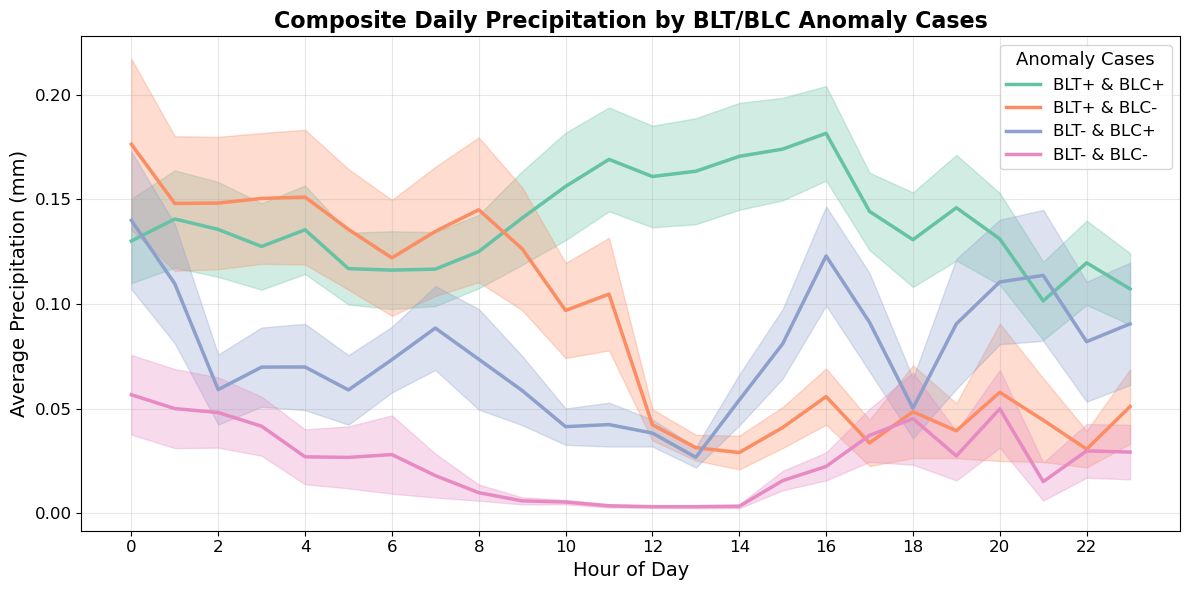

In [66]:
# Define the four cases
cases = {
    'BLT+ & BLC+': (small_master['blt_stnd_anom'] > 0) & (small_master['blc_stnd_anom'] > 0),
    'BLT+ & BLC-': (small_master['blt_stnd_anom'] > 0) & (small_master['blc_stnd_anom'] < 0),
    'BLT- & BLC+': (small_master['blt_stnd_anom'] < 0) & (small_master['blc_stnd_anom'] > 0),
    'BLT- & BLC-': (small_master['blt_stnd_anom'] < 0) & (small_master['blc_stnd_anom'] < 0),
}


# Set up figure
plt.figure(figsize=(12,6))

# Colorblind-friendly Set2 palette
colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']  

for (label, condition), color in zip(cases.items(), colors):
    subset = small_master[condition]

    if len(subset) == 0:
        continue  # skip empty cases

    # Convert lists to 2D array
    daily_array = np.vstack(subset['daily_precip'].to_numpy())

    # Compute mean and standard error
    mean_precip = np.nanmean(daily_array, axis=0)
    sem_precip = np.nanstd(daily_array, axis=0) / np.sqrt(daily_array.shape[0])

    # Plot mean
    plt.plot(mean_precip, label=label, color=color, linewidth=2.5)

    # Plot shaded standard error
    plt.fill_between(
        np.arange(mean_precip.size),
        mean_precip - sem_precip,
        mean_precip + sem_precip,
        color=color,
        alpha=0.3
    )

# Professional styling
plt.xlabel('Hour of Day', fontsize=14)

plt.ylabel('Average Precipitation (mm)', fontsize=14)

plt.title('Composite Daily Precipitation by BLT/BLC Anomaly Cases', fontsize=16, fontweight='bold')

plt.xticks(ticks=np.arange(0, 24, 2), labels=[str(h) for h in range(0, 24, 2)], fontsize=12)

plt.yticks(fontsize=12)

plt.grid(True, alpha=0.3)

plt.legend(title='Anomaly Cases', fontsize=12, title_fontsize=13)

plt.tight_layout()

plt.show()

In [67]:
# Step 1: Define predictors (raw values now)

X = small_master[["blt_stnd_anom", "blc_stnd_anom", "hilow_stnd_anom", "ctp_stnd_anom"]]

# Step 2: Define target (afternoon rainfall, same as before)

small_master["afternoon_rain"] = small_master["daily_precip"].apply(lambda arr: np.sum(arr[12:19]) if isinstance(arr, list) and len(arr) == 24 else np.nan)

y = small_master["afternoon_rain"]

X = X.loc[y.index]

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Fit Random Forest Regressor
rf = RandomForestRegressor(n_estimators=500, random_state=42)

rf.fit(X_train, y_train)

# Step 6: Evaluate
y_pred = rf.predict(X_test)

print("R²:", r2_score(y_test, y_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


/tmp/ipykernel_52522/1266345995.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  small_master["afternoon_rain"] = small_master["daily_precip"].apply(lambda arr: np.sum(arr[12:19]) if isinstance(arr, list) and len(arr) == 24 else np.nan)


R²: -0.015511376653062792
RMSE: 1.6848551874780868


In [17]:
# Select predictors and target

X = small_master[['blt_stnd_anom', 'blc_stnd_anom']]

y = small_master['rainfall_group']  # assumed categorical: 'trace', 'low', 'medium', 'heavy'

# Split into train and test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [18]:
rf_clf = RandomForestClassifier(
    
    n_estimators=500,
    
    class_weight='balanced',  # automatically weights rare classes higher
    
    max_depth=None,       # let trees grow fully
    
    random_state=42,
    
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=500, n_jobs=-1,
                       random_state=42)

In [20]:
# Predictions

y_pred = rf_clf.predict(X_test)

# print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       heavy       0.08      0.05      0.06        44
         low       0.38      0.33      0.35       160
      medium       0.29      0.23      0.25        71
       trace       0.63      0.75      0.68       276

    accuracy                           0.51       551
   macro avg       0.34      0.34      0.34       551
weighted avg       0.47      0.51      0.48       551



In [134]:
# ## this doesn't work because it doesn't handle zeros separately 

# def gamma_to_normal_z(x):
    
#     """Fit gamma to data x, return transformed z-scores."""
    
#     x = np.asarray(x)
            
#     if np.all(x == 0):  # handle degenerate case
        
#         return np.zeros_like(x, dtype=float)
    
#     shape, loc, scale = gamma.fit(x, floc=0)  # force loc=0 for precip
    
#     print("complete")
    
#     cdf_vals = gamma.cdf(x, shape, loc=loc, scale=scale)
    
#     # avoid 0 or 1 which cause inf after norm.ppf
    
#     cdf_vals = np.clip(cdf_vals, 1e-6, 1-1e-6)
    
#     # transform to normal quantiles (z-scores)
        
#     return norm.ppf(cdf_vals)

# master["afternoon_precip_gamma_z"] = (master.groupby(["latitude", "longitude", "calendar_day"])["afternoon_precip"].transform(gamma_to_normal_z))

In [136]:
# # example of how to handle zeros separately in order to get z-scores

# precip = np.array([
#     10.2653503, 0.0, 0.00905990601, 0.0, 0.0, 1.12676620, 2.35891342, 0.0,
#     0.20980835, 0.000476837158, 0.00143051147, 0.0, 0.0, 0.0, 0.0, 0.0,
#     0.0, 0.379562378
# ])

# def zero_inflated_gamma_zscore(x):
    
#     x = np.asarray(x, dtype=float)
    
#     # 1. Probability of zero precipitation
#     p0 = np.mean(x == 0)
    
#     # 2. Fit Gamma to positive values only
#     x_pos = x[x > 0]
    
#     # Edge case: all zeros
#     if len(x_pos) == 0:
        
#         return np.zeros_like(x)
    
#     shape, loc, scale = gamma.fit(x_pos, floc=0)
    
#     # 3. Compute CDF values for each x
#     cdf_vals = np.zeros_like(x, dtype=float)
    
#     cdf_vals[x == 0] = p0
    
#     cdf_vals[x > 0] = p0 + (1 - p0) * gamma.cdf(x[x > 0], shape, loc=0, scale=scale)
    
#     # 4. Avoid exact 0 or 1 for norm.ppf
#     cdf_vals = np.clip(cdf_vals, 1e-6, 1-1e-6)
    
#     # 5. Transform to standard normal z-scores
#     z_scores = norm.ppf(cdf_vals)
    
#     return z_scores

# # Compute z-scores
# z_scores = zero_inflated_gamma_zscore(precip)

# print("Z-scores:\n", z_scores)

# # Plot distribution
# plt.figure(figsize=(8,5))

# sns.histplot(z_scores, bins=10, kde=True, color='skyblue')

# plt.title('Zero-Inflated Gamma Z-Score Distribution')

# plt.xlabel('Z-score')

# plt.ylabel('Frequency')

# plt.grid(True, alpha=0.3)

# plt.show()

In [104]:
small_master = master[(master['latitude'] == 35) & (master['longitude'] == -100)]

small_master = small_master.dropna(subset=["afternoon_precip_anom"])

In [105]:
# select features and target

X = small_master[['blt_stnd_anom', 'blc_stnd_anom']]

y = small_master['afternoon_precip_anom']

# Optional: log-transform y if rainfall is skewed

# y = np.log1p(master['total_rainfall'])

In [106]:
# split into train/test splits

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [111]:
param_grid = {
    
    "n_estimators": [100, 300, 500],
    
    "max_depth": [None, 10, 20, 30],
    
    "min_samples_split": [2, 5, 10],
    
    "min_samples_leaf": [1, 2, 4],
    
    "max_features": ["sqrt", "log2", None]
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    
    estimator=rf,
    
    param_grid=param_grid,
    
    cv=5,               # 5-fold cross-validation
    
    scoring='r2',       # or 'neg_mean_squared_error'
    
    n_jobs=-1,
    
    verbose=2
)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)

print(grid_search.best_score_)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 500}
0.09147190647056964


In [107]:
rf = RandomForestRegressor(
    
    n_estimators=500,      # number of trees
    
    max_depth=None,        # let trees grow fully (can tune)
    
    random_state=42,
    
    n_jobs=-1              # use all CPU cores
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=500, n_jobs=-1, random_state=42)

In [108]:
# how well does rf predict?

y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)

rmse = mean_squared_error(y_test, y_pred, squared=False)

print(f"R²: {r2:.3f}")

print(f"RMSE: {rmse:.3f} mm/day")

R²: -0.002
RMSE: 0.937 mm/day
